<a href="https://colab.research.google.com/github/vnm19102-hub/Gen-AI-Assignments/blob/main/Hugging_Face_embeddings%2C_q%26A_bot_41229.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q sentence-transformers scikit-learn matplotlib

In [ ]:
from sentence_transformers import SentenceTransformer

# Load the free pre-trained model from Hugging Face
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
sentence = "I love learning about Generative Artificial Intelligence."

embedding = model.encode(sentence)

print("Sentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Sentence: I love learning about Generative Artificial Intelligence.
Embedding shape: (384,)
First 10 values: [-0.03489972 -0.11217742  0.07837665  0.017111   -0.00872299 -0.02432282
 -0.00683879  0.00047247  0.03821811  0.0472834 ]


In [ ]:
sentences = [
    "I love playing cricket",
    "I like to swim in the pool",
    "Dogs are loyal animals",
    "The stock market crashed today",
    "Cats are cute pets",
    "I went to Ooty trip with friends"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

Number of sentences: 6
Embedding matrix shape: (6, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

import pandas as pd
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df.round(2)

,I love playing cricket,I like to swim in the pool,Dogs are loyal animals,The stock market crashed today,Cats are cute pets,I went to Ooty trip with friends
I love playing cricket,1.00,0.41,0.11,-0.01,0.17,0.15
I like to swim in the pool,0.41,1.00,0.07,-0.01,0.28,0.27
Dogs are loyal animals,0.11,0.07,1.00,-0.06,0.46,0.01
The stock market crashed today,-0.01,-0.01,-0.06,1.00,0.05,0.06
Cats are cute pets,0.17,0.28,0.46,0.05,1.00,0.07
I went to Ooty trip with friends,0.15,0.27,0.01,0.06,0.07,1.00


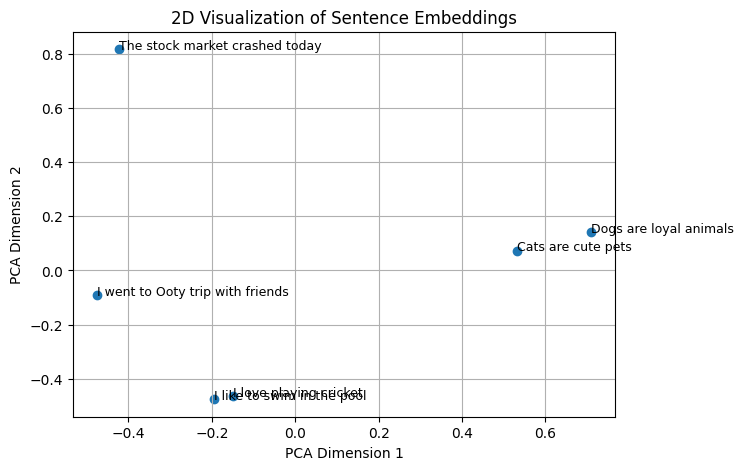

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, sent in enumerate(sentences):
    plt.annotate(sent, (reduced[i, 0], reduced[i, 1]), fontsize=9)

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

# SEMANTIC SEARCH

In [ ]:
# Our small "document" database
documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

# Encode all documents once
doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Rank documents by similarity score
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f}  |  {documents[idx]}")

# Try it
semantic_search("Tell me about AI and neural networks")
# Try another query
semantic_search("Where was the red sea located")


Query: Tell me about AI and neural networks

Score: 0.534  |  Deep learning uses neural networks with many layers.
Score: 0.524  |  Python is a popular programming language for AI.
Query: Where was the red sea located

Score: 0.087  |  Paris is the capital city of France.
Score: 0.020  |  The weather today is sunny and warm.


Practice Exercises

replacing doxument with our own words

In [ ]:
# Our small "document" database
documents = [
    "Mobile prices are increaing rapidly.",
    "Demand for rams and storage devices has been increased rapildly due to AI companies.",
    "Iphone Duo has priced at 3 lakh rupees.",
    "Sales starts from oct 9.",
    "U.S presuring Europe to release Diesel reserves.",
    "Max won the grand prix after 15 rounds.",
    "Virat just made his 86th centure in INT cricket.",
    "My laptop is working too slow.",
    "Decision had made to resize the world map.",
]

# Encode all documents once
doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Rank documents by similarity score
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f}  |  {documents[idx]}")

# Try it
semantic_search("when will U.S elections are going to occur")
semantic_search("where the iphones are made")

Query: when will U.S elections are going to occur

Score: 0.296  |  Sales starts from oct 9.
Score: 0.212  |  Mobile prices are increaing rapidly.
Query: where the iphones are made

Score: 0.351  |  Iphone Duo has priced at 3 lakh rupees.
Score: 0.280  |  Mobile prices are increaing rapidly.


using another free model

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Sample documents
documents = [
    "Machine learning allows computers to learn from data.",
    "Deep learning uses neural networks with multiple layers.",
    "Python is widely used for machine learning and data science.",
    "Natural language processing helps computers understand human language.",
    "Computer vision allows machines to understand images and videos.",
    "Artificial intelligence is used in many real-world applications.",
    "Data preprocessing is an important step in machine learning.",
    "Neural networks are inspired by the human brain.",
    "Semantic search finds information based on meaning.",
    "Embeddings represent text as numerical vectors."
]

# Query
query = "How do computers understand human language?"

# --------------------------------------------------
# MODEL 1: all-MiniLM-L6-v2
# --------------------------------------------------

model1 = SentenceTransformer("all-MiniLM-L6-v2")

document_embeddings1 = model1.encode(documents)
query_embedding1 = model1.encode([query])

similarities1 = cosine_similarity(
    query_embedding1,
    document_embeddings1
)[0]

print("Results using all-MiniLM-L6-v2:")
print()

for i in similarities1.argsort()[::-1]:
    print(f"{similarities1[i]:.4f} - {documents[i]}")


# --------------------------------------------------
# MODEL 2: all-mpnet-base-v2
# --------------------------------------------------

model2 = SentenceTransformer("all-mpnet-base-v2")

document_embeddings2 = model2.encode(documents)
query_embedding2 = model2.encode([query])

similarities2 = cosine_similarity(
    query_embedding2,
    document_embeddings2
)[0]

print("\nResults using all-mpnet-base-v2:")
print()

for i in similarities2.argsort()[::-1]:
    print(f"{similarities2[i]:.4f} - {documents[i]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Results using all-MiniLM-L6-v2:

0.6921 - Natural language processing helps computers understand human language.
0.4947 - Computer vision allows machines to understand images and videos.
0.4499 - Machine learning allows computers to learn from data.
0.3680 - Neural networks are inspired by the human brain.
0.3068 - Artificial intelligence is used in many real-world applications.
0.2747 - Deep learning uses neural networks with multiple layers.
0.2664 - Semantic search finds information based on meaning.
0.2620 - Embeddings represent text as numerical vectors.
0.2253 - Python is widely used for machine learning and data science.
0.2234 - Data preprocessing is an important step in machine learning.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Results using all-mpnet-base-v2:

0.5978 - Natural language processing helps computers understand human language.
0.4680 - Computer vision allows machines to understand images and videos.
0.4106 - Machine learning allows computers to learn from data.
0.3535 - Embeddings represent text as numerical vectors.
0.3485 - Artificial intelligence is used in many real-world applications.
0.3295 - Deep learning uses neural networks with multiple layers.
0.3253 - Data preprocessing is an important step in machine learning.
0.3025 - Semantic search finds information based on meaning.
0.2834 - Neural networks are inspired by the human brain.
0.2698 - Python is widely used for machine learning and data science.


# Building Q & A bot


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")



faq = [
    {
        "question": "What is machine learning?",
        "answer": "Machine learning is a branch of AI that allows computers to learn from data."
    },
    {
        "question": "What is deep learning?",
        "answer": "Deep learning is a type of machine learning that uses neural networks with multiple layers."
    },
    {
        "question": "What is Python?",
        "answer": "Python is a popular programming language widely used for AI, machine learning, and data science."
    },
    {
        "question": "What is artificial intelligence?",
        "answer": "Artificial intelligence is the field of creating systems that can perform tasks requiring human-like intelligence."
    },
    {
        "question": "What is NLP?",
        "answer": "Natural Language Processing is a field of AI that enables computers to understand and process human language."
    }
]



questions = [item["question"] for item in faq]

# Create embeddings for FAQ questions
question_embeddings = model.encode(questions)



def faq_bot(user_question):

    # Convert user's question into an embedding
    user_embedding = model.encode([user_question])

    # Calculate similarity with all FAQ questions
    similarities = cosine_similarity(
        user_embedding,
        question_embeddings
    )[0]

    # Find the most similar question
    best_index = similarities.argmax()

    # Get similarity score
    best_score = similarities[best_index]

    # Get corresponding answer
    answer = faq[best_index]["answer"]

    print("User:", user_question)
    print("Matched FAQ:", faq[best_index]["question"])
    print("Similarity:", round(best_score, 4))
    print("Answer:", answer)



faq_bot("Can you explain machine learning?")
faq_bot("Tell me about artificial intelligence")
faq_bot("Explain deep neural networks")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

User: Can you explain machine learning?
Matched FAQ: What is machine learning?
Similarity: 0.8468
Answer: Machine learning is a branch of AI that allows computers to learn from data.
User: Tell me about artificial intelligence
Matched FAQ: What is artificial intelligence?
Similarity: 0.8741
Answer: Artificial intelligence is the field of creating systems that can perform tasks requiring human-like intelligence.
User: Explain deep neural networks
Matched FAQ: What is deep learning?
Similarity: 0.7509
Answer: Deep learning is a type of machine learning that uses neural networks with multiple layers.
